In [1]:
import numpy as np
import matplotlib.pyplot as plt


Iteration  1 | Centroid shift: 1.8328 | Label changes: 28
Iteration  2 | Centroid shift: 2.1321 | Label changes: 23
Iteration  3 | Centroid shift: 1.3828 | Label changes: 4
Iteration  4 | Centroid shift: 0.2686 | Label changes: 1
Iteration  5 | Centroid shift: 0.0870 | Label changes: 0
Iteration  6 | Centroid shift: 0.0000 | Label changes: 0
Converged ✅


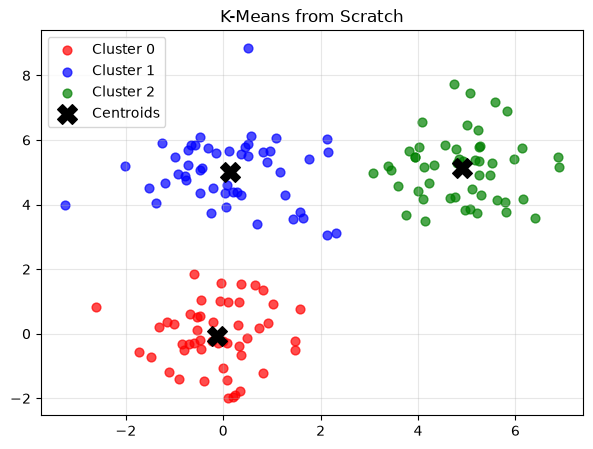

In [2]:
# Cell 2 — Version 1: K-Means from scratch (step by step)
np.random.seed(42)
# 3 natural clusters
X = np.vstack([
    np.random.randn(50, 2) + [0, 0],
    np.random.randn(50, 2) + [5, 5],
    np.random.randn(50, 2) + [0, 5]
])

K = 3
# randomly initialise centroids from data points
centroids = X[np.random.choice(len(X), K, replace=False)]

def assign_clusters(X, centroids):
    distances = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X])
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, K):
    return np.array([X[labels == k].mean(axis=0) for k in range(K)])

labels = assign_clusters(X, centroids)
for iteration in range(10):
    new_centroids = update_centroids(X, labels, K)
    new_labels    = assign_clusters(X, new_centroids)
    print(f"Iteration {iteration+1:2d} | "
          f"Centroid shift: {np.linalg.norm(new_centroids - centroids):.4f} | "
          f"Label changes: {np.sum(new_labels != labels)}")
    if np.allclose(centroids, new_centroids):
        print("Converged ✅")
        break
    centroids, labels = new_centroids, new_labels

colors = ['red', 'blue', 'green']
plt.figure(figsize=(7, 5))
for k in range(K):
    mask = labels == k
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=40,
                alpha=0.7, label=f'Cluster {k}')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200,
            marker='X', zorder=5, label='Centroids')
plt.title('K-Means from Scratch'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

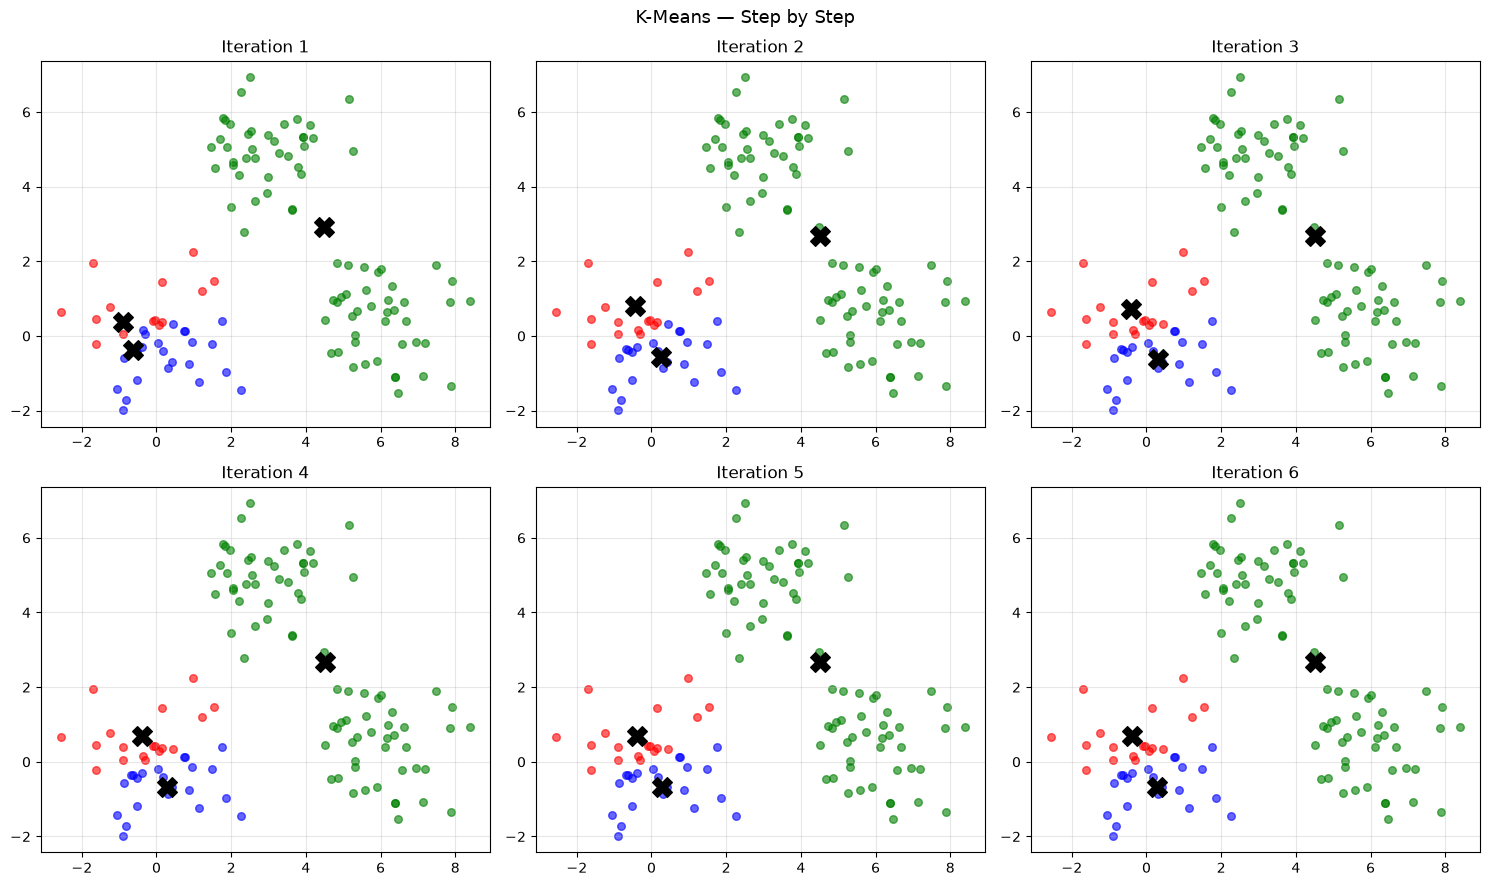

In [3]:
# Cell 3 — Version 2: visualise each iteration
np.random.seed(0)
X = np.vstack([
    np.random.randn(40, 2) + [0, 0],
    np.random.randn(40, 2) + [6, 0],
    np.random.randn(40, 2) + [3, 5]
])

K = 3
centroids = X[np.random.choice(len(X), K, replace=False)]
colors    = ['red', 'blue', 'green']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for step in range(6):
    labels    = assign_clusters(X, centroids)
    ax        = axes[step]
    for k in range(K):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=30, alpha=0.6)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200,
               marker='X', zorder=5)
    ax.set_title(f'Iteration {step+1}'); ax.grid(True, alpha=0.3)
    centroids = update_centroids(X, labels, K)

plt.suptitle('K-Means — Step by Step', fontsize=13)
plt.tight_layout(); plt.show()

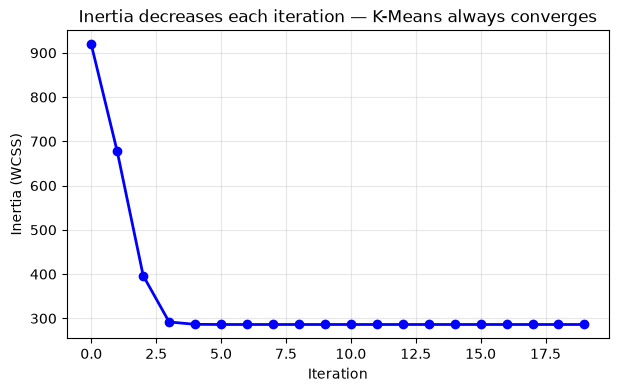

Final inertia: 286.18


In [4]:
# Cell 4 — Version 3: inertia (WCSS) — what K-Means minimises
# Inertia = sum of squared distances from each point to its centroid
# K-Means minimises this

def compute_inertia(X, labels, centroids):
    return sum(np.sum((X[labels == k] - centroids[k])**2)
               for k in range(len(centroids)))

np.random.seed(42)
X = np.vstack([
    np.random.randn(50, 2) + [0, 0],
    np.random.randn(50, 2) + [5, 5],
    np.random.randn(50, 2) + [0, 5]
])

K = 3
centroids = X[np.random.choice(len(X), K, replace=False)]
inertias  = []

for i in range(20):
    labels     = assign_clusters(X, centroids)
    inertias.append(compute_inertia(X, labels, centroids))
    centroids  = update_centroids(X, labels, K)

plt.figure(figsize=(7, 4))
plt.plot(inertias, 'b-o', linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('Inertia (WCSS)')
plt.title('Inertia decreases each iteration — K-Means always converges')
plt.grid(True, alpha=0.3); plt.show()
print(f"Final inertia: {inertias[-1]:.2f}")

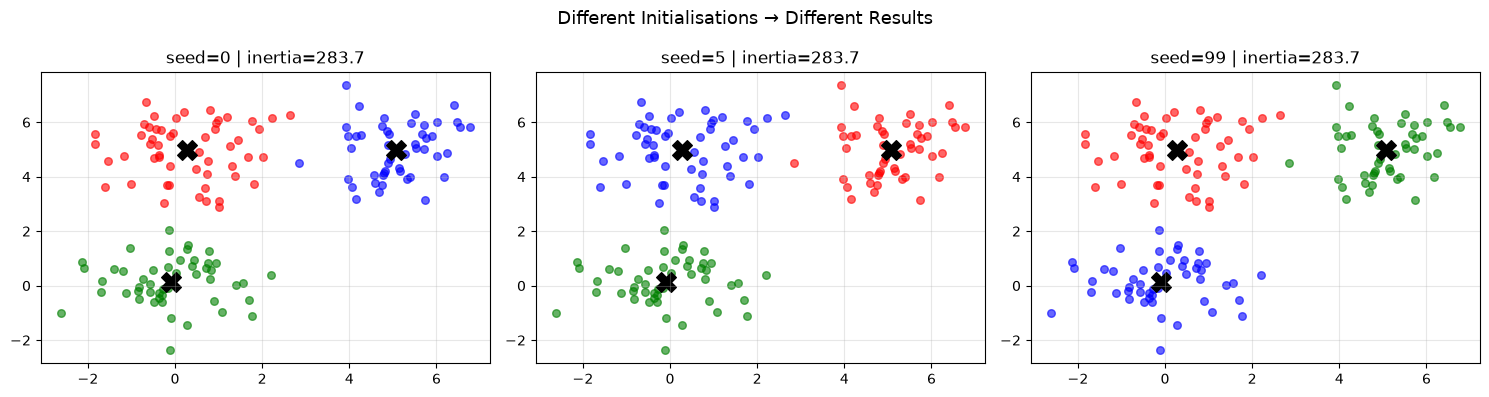

K-Means++ (sklearn default) solves bad init problem ✅


In [5]:
# Cell 5 — Version 4: effect of bad initialisation (why K-Means++ matters)
np.random.seed(99)
X = np.vstack([
    np.random.randn(50, 2) + [0, 0],
    np.random.randn(50, 2) + [5, 5],
    np.random.randn(50, 2) + [0, 5]
])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['red', 'blue', 'green']

for ax, seed in zip(axes, [0, 5, 99]):
    np.random.seed(seed)
    centroids = X[np.random.choice(len(X), 3, replace=False)]
    for _ in range(20):
        labels    = assign_clusters(X, centroids)
        centroids = update_centroids(X, labels, K)
    inertia = compute_inertia(X, labels, centroids)
    for k in range(3):
        ax.scatter(X[labels==k, 0], X[labels==k, 1],
                   c=colors[k], s=30, alpha=0.6)
    ax.scatter(centroids[:,0], centroids[:,1], c='black', s=200, marker='X')
    ax.set_title(f'seed={seed} | inertia={inertia:.1f}')
    ax.grid(True, alpha=0.3)

plt.suptitle('Different Initialisations → Different Results', fontsize=13)
plt.tight_layout(); plt.show()
print("K-Means++ (sklearn default) solves bad init problem ✅")